In [94]:
import neuscitk as ntk
import matplotlib.pyplot as plt   #plots
import numpy as np                #arrays
import seaborn as sb              #extra plots
dataset = ntk.LabChartDataset('/Users/simon765/Downloads/Lab1_Demo_Data.mat')


In [95]:
page_map = {
    'Step_triangle' : list(range(0,60)),
    'Sine_chirps' : list(range(60,120)),
    'Spontaneous' : list(range(120,180))
}

dataset.organize_by_pages(page_map)

In [96]:
Step_triangles_Trials = dataset.get_page('Step_triangle')
Sine_chirps_Trials = dataset.get_page('Sine_chirps')
Spontaneous_Trials = dataset.get_page('Spontaneous')

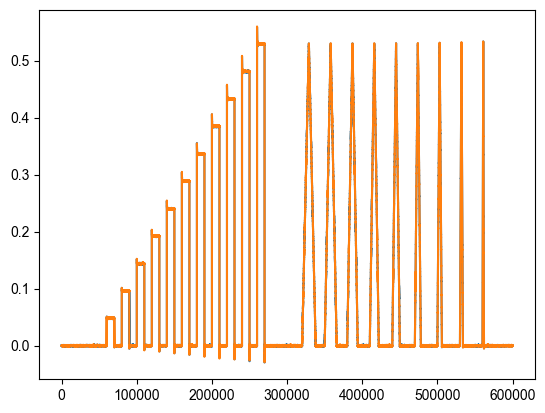

In [97]:
#plt.plot(group[page number][channel])
#range of windows for step & triangles
plt.plot(Step_triangles_Trials['block_59'][1])
plt.plot(Step_triangles_Trials['block_0'][1])



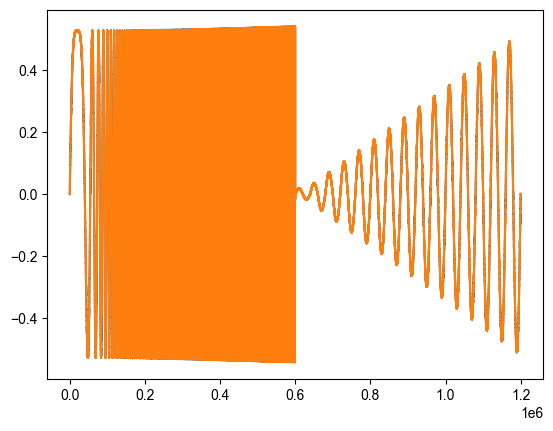

In [98]:
plt.plot(Sine_chirps_Trials['block_60'][1])
plt.plot(Sine_chirps_Trials['block_119'][1])


(-0.5, 0.5)

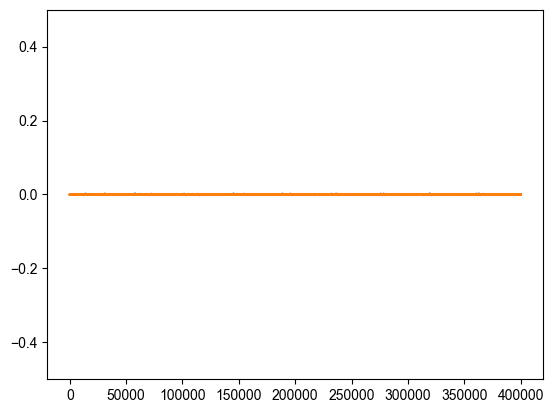

In [99]:
plt.plot(Spontaneous_Trials['block_120'][1])
plt.plot(Spontaneous_Trials['block_179'][1])
# Manually set y-axis range
plt.ylim(-0.5, 0.5)

Text(0, 0.5, 'mV')

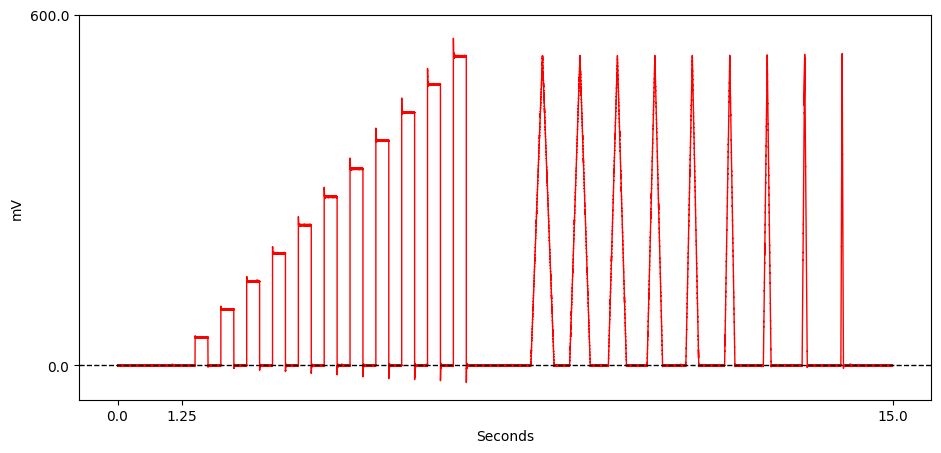

In [12]:
SR = 40000

# Plotting
plt.figure(figsize=(11, 5))
plt.plot(Step_triangles_Trials['block_0'][1],
         color = 'red',
         linewidth = 1
         )

# x-Axis
xticks_samples = np.array([0, 600000, 50000])
xticks_seconds = xticks_samples / SR
plt.xticks(xticks_samples,xticks_seconds) 


# y-Axis
yticks_samples = np.array([0,0.6])
yticks_seconds = yticks_samples * 1000
plt.yticks(yticks_samples,yticks_seconds)

baseline_mV = 0
baseline_V = baseline_mV / 1000
plt.axhline(y=baseline_V, color='black', linestyle='--', linewidth=1) # Notice hline is for a horizontal line!

plt.xlabel("Seconds")       # Label for x-axis
plt.ylabel("mV")         # Label for y-axis



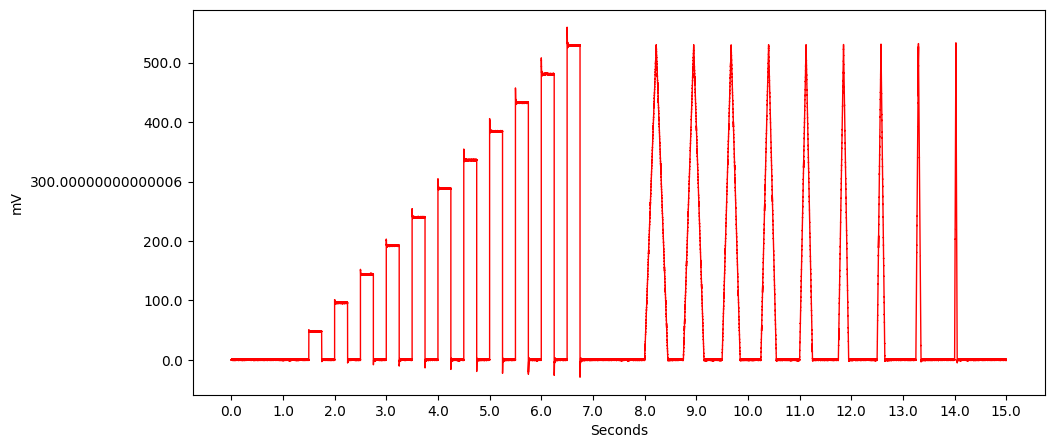

In [13]:
SR = 40000  # sampling rate
data = Step_triangles_Trials['block_0'][1]
num_samples = len(data)

plt.figure(figsize=(11, 5))
plt.plot(data, color='red', linewidth=1)

# --- X-Axis ---
# Let's make a tick every 1 second up to the duration of the trace
duration_sec = num_samples / SR
xticks_seconds = np.arange(0, duration_sec + 1, 1)   # tick every 1 second
xticks_samples = xticks_seconds * SR
plt.xticks(xticks_samples, xticks_seconds)

# --- Y-Axis ---
# Tick every 0.1 V (100 mV)
yticks_volts = np.arange(0, 0.6, 0.1)
yticks_mV = yticks_volts * 1000
plt.yticks(yticks_volts, yticks_mV)


plt.xlabel("Seconds")
plt.ylabel("mV")

plt.show()

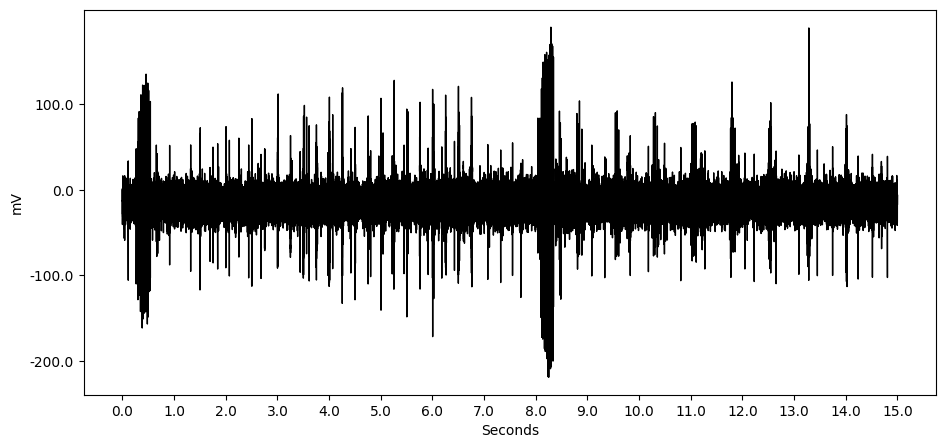

In [83]:
SR = 40000  # sampling rate
data = Step_triangles_Trials['block_0'][0]
num_samples = len(data)

plt.figure(figsize=(11, 5))
plt.plot(data, color='black', linewidth=1)

# --- X-Axis ---
# Let's make a tick every 1 second up to the duration of the trace
duration_sec = num_samples / SR
xticks_seconds = np.arange(0, duration_sec + 1, 1)   # tick every 1 second
xticks_samples = xticks_seconds * SR
plt.xticks(xticks_samples, xticks_seconds)

# --- Y-Axis ---
# Tick every 0.1 V (100 mV)
yticks_volts = np.arange(-0.2, 0.2, 0.1)
yticks_mV = yticks_volts * 1000
plt.yticks(yticks_volts, yticks_mV)


plt.xlabel("Seconds")
plt.ylabel("mV")

plt.show()

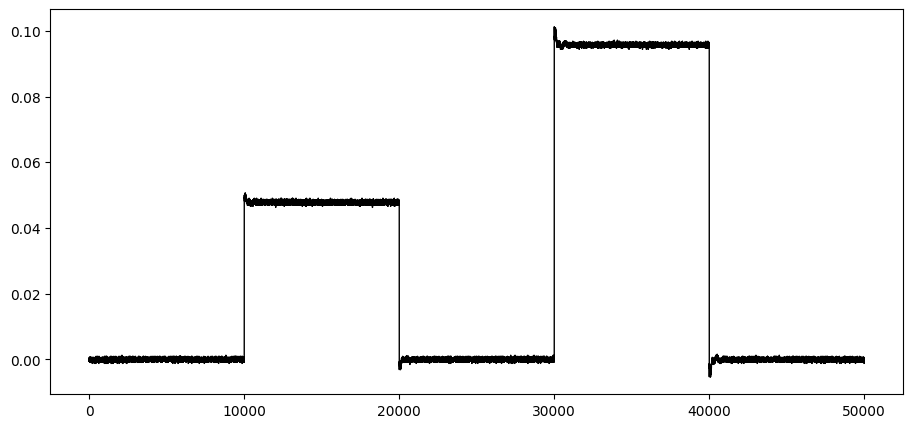

In [90]:
SR = 40000  # sampling rate
data = Step_triangles_Trials['block_0'][1]

start_idx = 50000
end_idx = 100000

plt.figure(figsize=(11, 5))
plt.plot(data[start_idx:end_idx], color='black', linewidth=1)

(array([ 14340,  15003,  15669,  16331,  16995,  17658,  18321,  18985,
        19650,  20312,  21639, 120595, 120597, 160261, 170288, 170434,
       170438, 200175, 210256, 210431, 230454, 240169, 241055, 250248,
       260167, 270254, 270256, 324428, 324764, 325092, 325427, 325755,
       326091, 326419, 326755, 327082, 327418, 327747, 328082, 328410,
       328745, 329074, 329409, 329736, 330072, 330400, 330736, 331063,
       331399, 331728, 332064, 332391, 332726, 333056, 333390, 333719,
       353850, 471937, 501938, 531433, 531435]), {'peak_heights': array([0.111     , 0.10525   , 0.12234375, 0.11426563, 0.12196875,
       0.11517187, 0.13509375, 0.122375  , 0.12467188, 0.11607812,
       0.10317188, 0.1083125 , 0.11196875, 0.10829688, 0.1135    ,
       0.11829688, 0.11917187, 0.10689063, 0.10645313, 0.127875  ,
       0.10226563, 0.11732812, 0.10020313, 0.110625  , 0.120875  ,
       0.108     , 0.10548437, 0.11803125, 0.10815625, 0.13067187,
       0.113125  , 0.14918751, 0.1

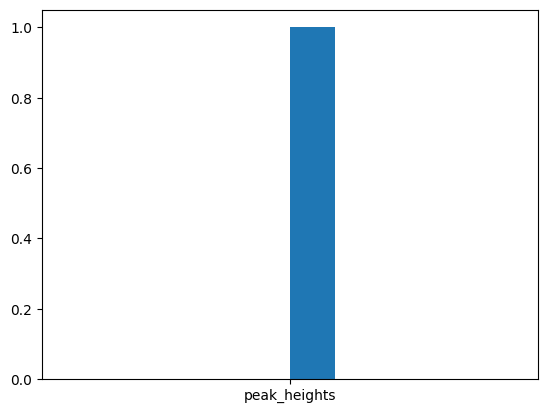


Analyzing block_0...

Analyzing block_1...

Analyzing block_2...


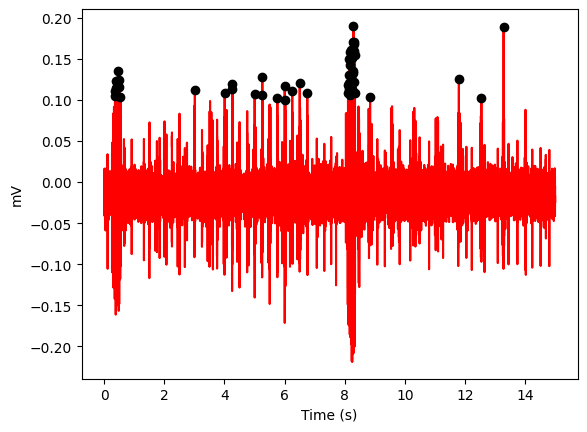

In [32]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

data = Step_triangles_Trials['block_0'][0]
SR = 40000  # Hz
time = np.arange(len(data)) / SR  # seconds


# analyze only a few trials so it doesn't overload your computer
blocks_to_analyze = ['block_0', 'block_1', 'block_2']

for block_id in blocks_to_analyze:
    print(f"\nAnalyzing {block_id}...")

peaks, properties = find_peaks(data, height=0.1, distance=10)  # adjust height as needed
spike_times = time[peaks]

plt.plot(time, data, color='red')
plt.plot(spike_times, data[peaks], 'ko')  # mark spikes
plt.xlabel("Time (s)")
plt.ylabel("mV")
plt.show()



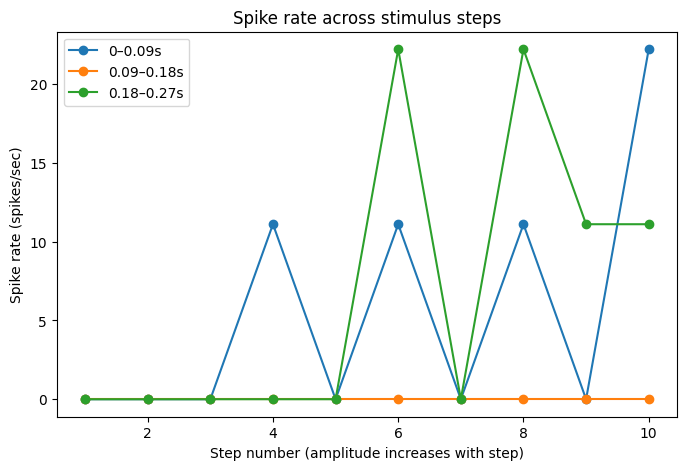

In [33]:
n_steps = 10  # or however many visible
step_starts = np.arange(1.5, 1.5 + n_steps*0.5, 0.5)
step_duration = 0.25

rates_early, rates_mid, rates_late = [], [], []

for t_start in step_starts:
    # define windows
    windows = [(t_start, t_start+0.09),
               (t_start+0.09, t_start+0.18),
               (t_start+0.18, t_start+0.27)]
    
    # count spikes in each
    for i, (w_start, w_end) in enumerate(windows):
        spikes_in_window = np.sum((spike_times >= w_start) & (spike_times < w_end))
        rate = spikes_in_window / (w_end - w_start)  # spikes/sec
        if i == 0:
            rates_early.append(rate)
        elif i == 1:
            rates_mid.append(rate)
        else:
            rates_late.append(rate)

steps = np.arange(1, len(step_starts)+1)

plt.figure(figsize=(8,5))
plt.plot(steps, rates_early, 'o-', label='0–0.09s')
plt.plot(steps, rates_mid, 'o-', label='0.09–0.18s')
plt.plot(steps, rates_late, 'o-', label='0.18–0.27s')

plt.xlabel("Step number (amplitude increases with step)")
plt.ylabel("Spike rate (spikes/sec)")
plt.title("Spike rate across stimulus steps")
plt.legend()
plt.show()


Analyzing block_0...


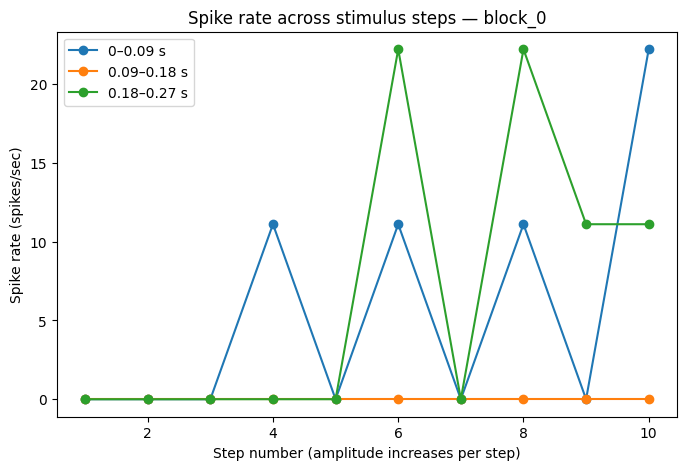


Analyzing block_1...


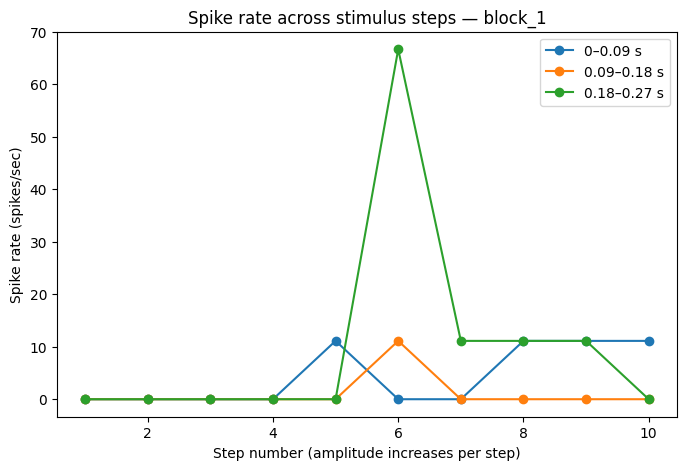


Analyzing block_2...


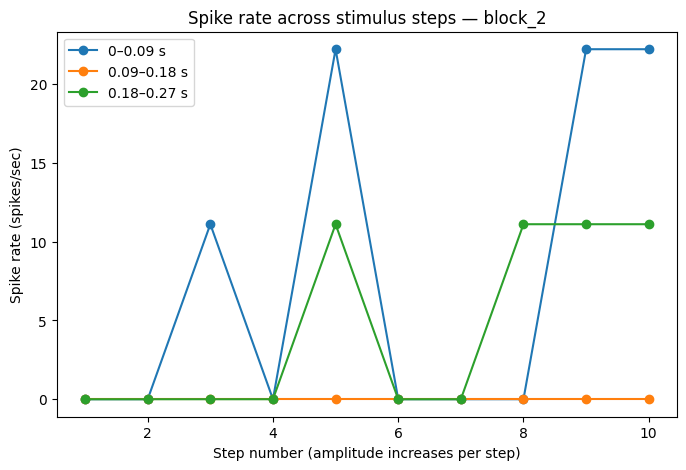

In [ ]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

SR = 40000  # sampling rate

# analyze only a few trials so it doesn't overload your computer
blocks_to_analyze = ['block_0', 'block_1', 'block_2']

for block_id in blocks_to_analyze:
    print(f"\nAnalyzing {block_id}...")
    
    # ===== Step 2: get data and time axis =====
    data = Step_triangles_Trials[block_id][0]
    time = np.arange(len(data)) / SR

    # ===== Step 3: detect spikes =====
    peaks, properties = find_peaks(data, height=0.1, distance=10)  # adjust height threshold as needed
    spike_times = time[peaks]

    # ===== Step 4: define step times =====
    n_steps = 11  # adjust to match your data
    step_starts = np.arange(1.5, 1.5 + n_steps * 0.5, 0.5)
    step_duration = 0.25

    # ===== Step 5: calculate spike rates for 3 × 0.09 s windows =====
    rates_early, rates_mid, rates_late = [], [], []

    for t_start in step_starts:
        windows = [
            (t_start, t_start + 0.09),
            (t_start + 0.09, t_start + 0.18),
            (t_start + 0.18, t_start + 0.27)
        ]
        for i, (w_start, w_end) in enumerate(windows):
            spikes_in_window = np.sum((spike_times >= w_start) & (spike_times < w_end))
            rate = spikes_in_window / (w_end - w_start)
            if i == 0:
                rates_early.append(rate)
            elif i == 1:
                rates_mid.append(rate)
            else:
                rates_late.append(rate)

    # ===== Step 6: plot spike rate vs. step amplitude =====
    steps = np.arange(1, len(step_starts) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(steps, rates_early, 'o-', label='0–0.09 s')
    plt.plot(steps, rates_mid, 'o-', label='0.09–0.18 s')
    plt.plot(steps, rates_late, 'o-', label='0.18–0.27 s')
    plt.xlabel("Step number (amplitude increases per step)")
    plt.ylabel("Spike rate (spikes/sec)")
    plt.title(f"Spike rate across stimulus steps — {block_id}")
    plt.legend()
    plt.show()


Analyzing block_0...


<Figure size 800x500 with 0 Axes>

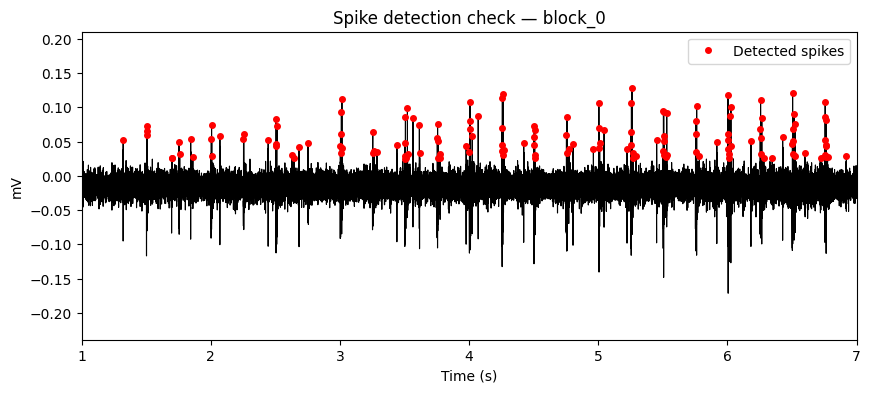


Analyzing block_1...


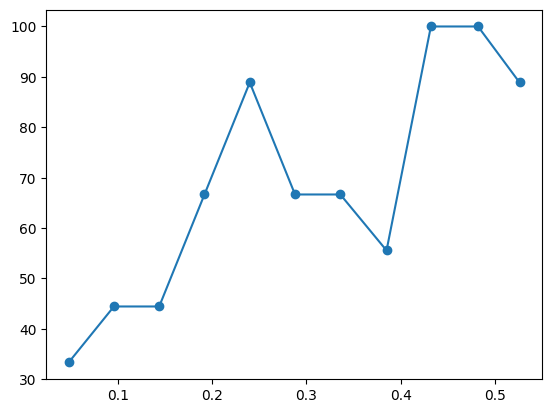

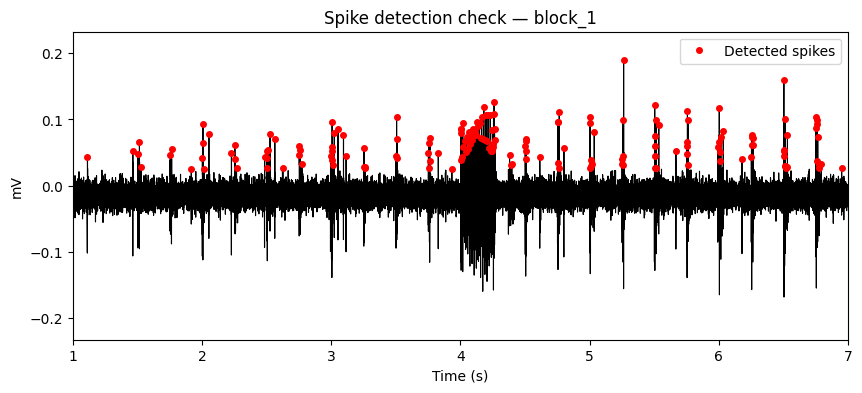


Analyzing block_2...


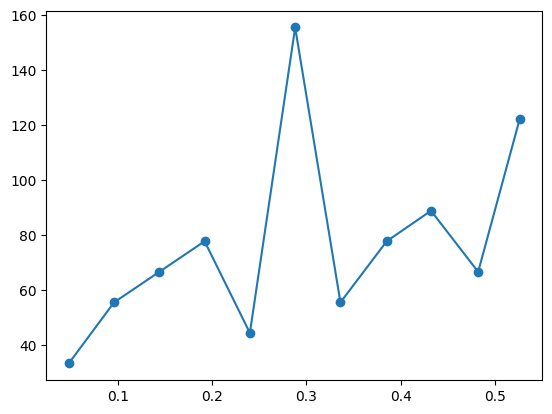

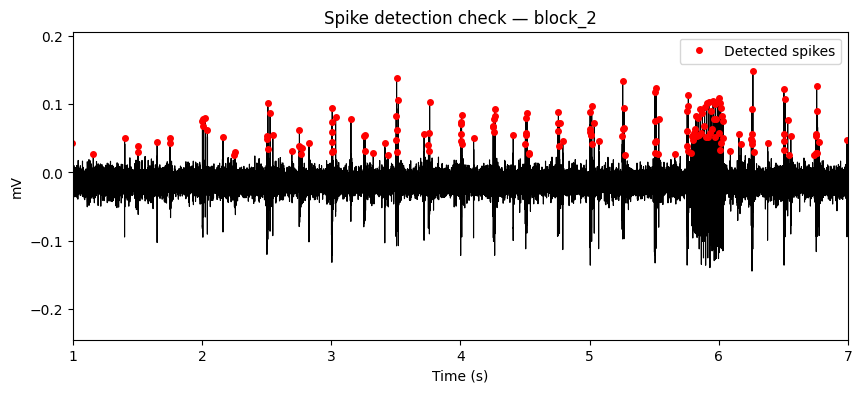


Analyzing block_3...


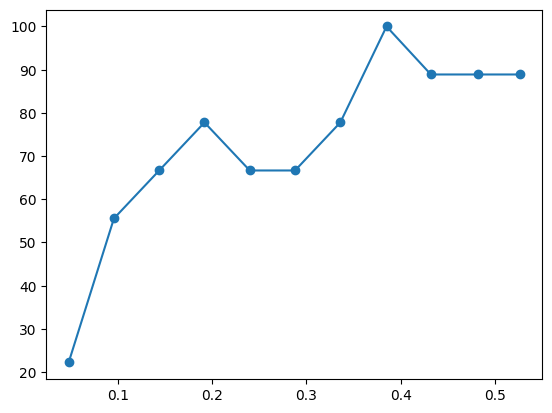

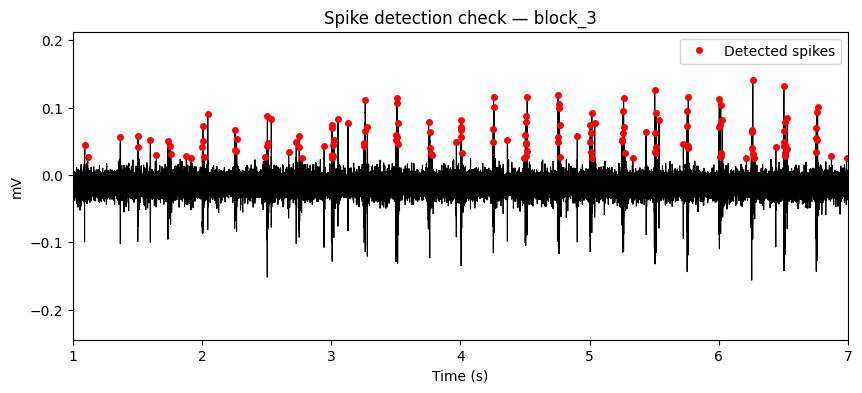


Analyzing block_4...


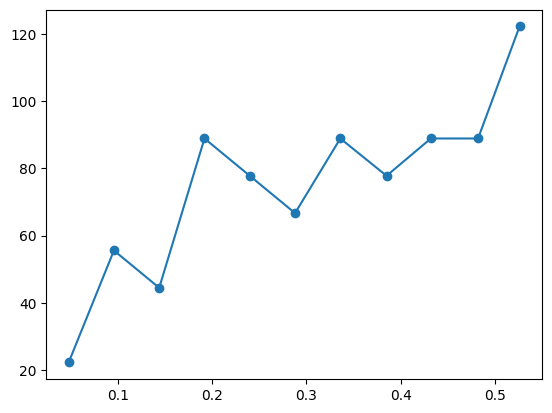

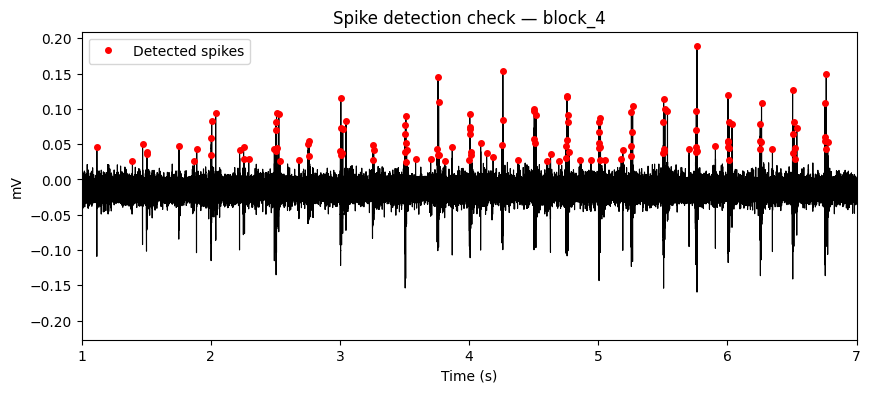

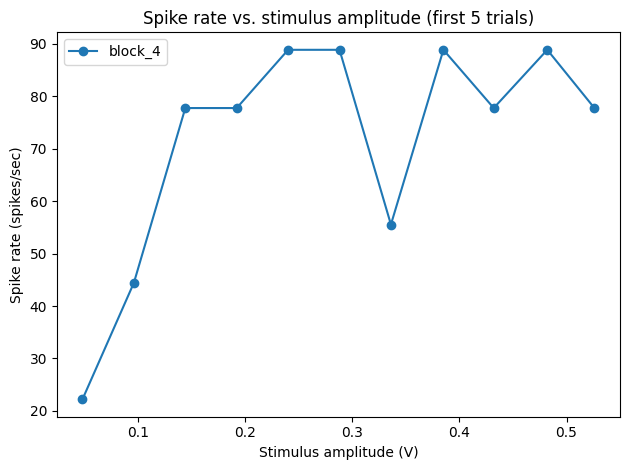

In [40]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

SR = 40000  # sampling rate

# --- Define amplitudes and their corresponding stimulus times ---
amplitudes = np.array([0.048, 0.096, 0.144, 0.192, 0.240,
                       0.288, 0.336, 0.385, 0.432, 0.482, 0.526])

step_windows = [
    (1.50, 1.59),
    (2.00, 2.09),
    (2.50, 2.59),
    (3.00, 3.09),
    (3.50, 3.59),
    (4.00, 4.09),
    (4.50, 4.59),
    (5.00, 5.09),
    (5.50, 5.59),
    (6.00, 6.09),
    (6.50, 6.59)
]

# --- Select trials and channel ---
blocks_to_analyze = ['block_0', 'block_1', 'block_2', 'block_3', 'block_4']
channel_index = 0  # use channel 0 for spike rate measurement

# --- Spike detection and plotting ---
plt.figure(figsize=(8, 5))

for block_id in blocks_to_analyze:
    print(f"\nAnalyzing {block_id}...")

    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR

    # detect spikes (tune 'height' or 'distance' as needed)
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.001))  # min 1 ms apart
    spike_times = time[peaks]

    # 🔍 VISUAL CHECK for spike detection (optional)
    # show a short 2-second window around stimulus onset for clarity
    plt.figure(figsize=(10, 4))
    plt.plot(time, data, color='black', linewidth=0.8)
    plt.plot(spike_times, data[peaks], 'ro', markersize=4, label='Detected spikes')
    plt.xlim(1.0, 7.0)  # zoom in to stimulus period
    plt.xlabel("Time (s)")
    plt.ylabel("mV")
    plt.title(f"Spike detection check — {block_id}")
    plt.legend()
    plt.show()

    # --- Compute spike rates in each window ---
    spike_rates = []
    for (t_start, t_end) in step_windows:
        spikes_in_window = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_window / (t_end - t_start)
        spike_rates.append(rate)

    # --- Plot spike rate vs amplitude for each trial ---
    plt.figure(1)
    plt.plot(amplitudes, spike_rates, 'o-', label=block_id)

# --- Final combined plot ---
plt.figure(1)
plt.xlabel("Stimulus amplitude (V)")
plt.ylabel("Spike rate (spikes/sec)")
plt.title("Spike rate vs. stimulus amplitude (first 5 trials)")
plt.legend()
plt.tight_layout()
plt.show()


Analyzing block_0...

Analyzing block_1...

Analyzing block_2...

Analyzing block_3...

Analyzing block_4...

Analyzing block_5...

Analyzing block_6...

Analyzing block_7...

Analyzing block_8...

Analyzing block_9...

Analyzing block_10...

Analyzing block_11...

Analyzing block_12...

Analyzing block_13...

Analyzing block_14...

Analyzing block_15...

Analyzing block_16...

Analyzing block_17...

Analyzing block_18...

Analyzing block_19...

Analyzing block_20...

Analyzing block_21...

Analyzing block_22...

Analyzing block_23...

Analyzing block_24...

Analyzing block_25...

Analyzing block_26...

Analyzing block_27...

Analyzing block_28...

Analyzing block_29...

Analyzing block_30...

Analyzing block_31...

Analyzing block_32...

Analyzing block_33...

Analyzing block_34...

Analyzing block_35...

Analyzing block_36...

Analyzing block_37...

Analyzing block_38...

Analyzing block_39...

Analyzing block_40...

Analyzing block_41...

Analyzing block_42...

Analyzing block_43..

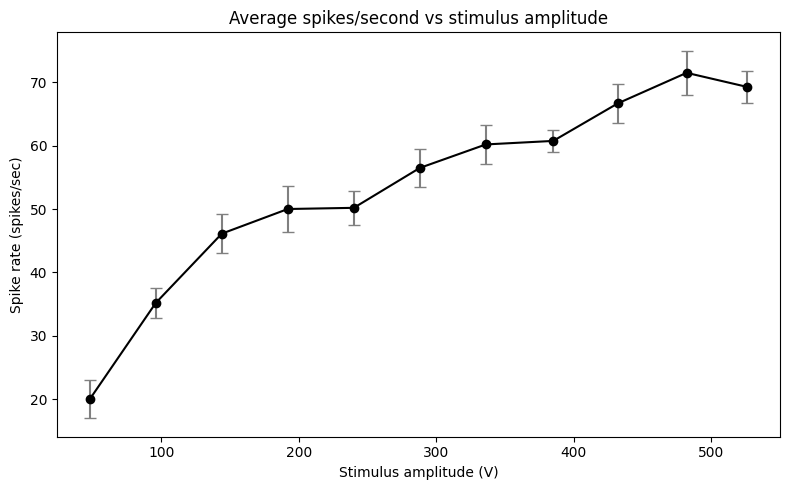

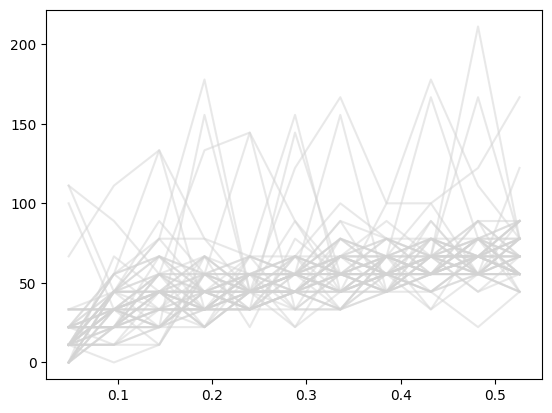

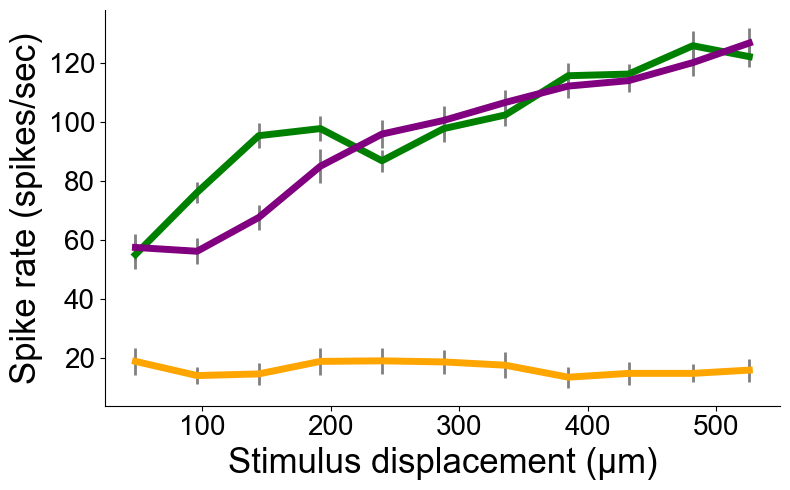

In [141]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

SR = 40000  # sampling rate

# --- define amplitudes and their corresponding stimulus times ---
amplitudes = np.array([0.048, 0.096, 0.144, 0.192, 0.240,
                       0.288, 0.336, 0.385, 0.432, 0.482, 0.526])

step_windows_start = [
    (1.50, 1.59),
    (2.00, 2.09),
    (2.50, 2.59),
    (3.00, 3.09),
    (3.50, 3.59),
    (4.00, 4.09),
    (4.50, 4.59),
    (5.00, 5.09),
    (5.50, 5.59),
    (6.00, 6.09),
    (6.50, 6.59)
]

step_windows_mid = [
    (1.59, 1.68),
    (2.09, 2.18),
    (2.59, 2.68),
    (3.09, 3.18),
    (3.59, 3.68),
    (4.09, 4.18),
    (4.59, 4.68),
    (5.09, 5.18),
    (5.59, 5.68),
    (6.09, 6.18),
    (6.59, 6.68)
]

step_windows_end = [
    (1.68, 1.77),
    (2.18, 2.27),
    (2.68, 2.77),
    (3.18, 3.27),
    (3.68, 3.77),
    (4.18, 4.27),
    (4.68, 4.77),
    (5.18, 5.27),
    (5.68, 5.77),
    (6.18, 6.27),
    (6.68, 6.77)
]

# --- analyze first 5 trials (channel 0) ---
blocks_to_analyze = ['block_0', 'block_1', 'block_2', 'block_3', 'block_4','block_5', 'block_6', 'block_7', 'block_8', 'block_9',
                     'block_10', 'block_11', 'block_12', 'block_13', 'block_14','block_15', 'block_16', 'block_17', 'block_18', 'block_19',
                     'block_20', 'block_21', 'block_22', 'block_23', 'block_24','block_25', 'block_26', 'block_27', 'block_28', 'block_29',
                     'block_30', 'block_31', 'block_32', 'block_33', 'block_34','block_35', 'block_36', 'block_37', 'block_38', 'block_39',
                     'block_40', 'block_41', 'block_42', 'block_43', 'block_44','block_45', 'block_46', 'block_47', 'block_48', 'block_49',
                     'block_50', 'block_51', 'block_52', 'block_53', 'block_54','block_55', 'block_56', 'block_57', 'block_58', 'block_59',]
channel_index = 0

# store spike rate data across trials
all_spike_rates_start = []
all_spike_rates_mid = []
all_spike_rates_end = []

for block_id in blocks_to_analyze:

    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR

    # detect spikes (use the height you’ve already tuned)
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
    spike_times = time[peaks]

    # compute spike rates for each amplitude window
    spike_rates_start = []
    spike_rates_mid = []
    spike_rates_end = []

    for (t_start, t_end) in step_windows_start:
        spikes_in_window = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_window / (t_end - t_start)
        spike_rates_start.append(rate)
    for (t_start, t_end) in step_windows_mid:
        spikes_in_window = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_window / (t_end - t_start)
        spike_rates_mid.append(rate)
    for (t_start, t_end) in step_windows_end:
        spikes_in_window = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_window / (t_end - t_start)
        spike_rates_end.append(rate)
    all_spike_rates_start.append(spike_rates_start)
    all_spike_rates_mid.append(spike_rates_mid)
    all_spike_rates_end.append(spike_rates_end)

# --- convert list to numpy array (shape: trials × amplitudes) ---
all_spike_rates_start = np.array(all_spike_rates_start)
all_spike_rates_mid = np.array(all_spike_rates_mid)
all_spike_rates_end = np.array(all_spike_rates_end)

# --- compute mean and SEM across trials ---
mean_rates_start = np.mean(all_spike_rates_start, axis=0)
sem_rates_start = np.std(all_spike_rates_start, axis=0, ddof=1) / np.sqrt(all_spike_rates_start.shape[0])

mean_rates_mid = np.mean(all_spike_rates_mid, axis=0)
sem_rates_mid = np.std(all_spike_rates_mid, axis=0, ddof=1) / np.sqrt(all_spike_rates_mid.shape[0])

mean_rates_end = np.mean(all_spike_rates_end, axis=0)
sem_rates_end = np.std(all_spike_rates_end, axis=0, ddof=1) / np.sqrt(all_spike_rates_end.shape[0])

# --- turn ammplitudes from V to mV ---
amplitude_um = amplitudes *1000


# --- final plot: averaged spike rate vs amplitude ---
plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(8, 5))
plt.errorbar(amplitude_um, mean_rates_start, yerr=sem_rates_start, fmt='-', capsize=0, color='green', ecolor='gray', linewidth=5, elinewidth=2)
plt.errorbar(amplitude_um, mean_rates_mid, yerr=sem_rates_mid, fmt='-', capsize=0, color='orange', ecolor='gray', linewidth=5, elinewidth=2)
plt.errorbar(amplitude_um, mean_rates_end, yerr=sem_rates_end, fmt='-', capsize=0, color='purple', ecolor='gray', linewidth=5, elinewidth=2)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Stimulus displacement (μm)", fontsize=25)
plt.ylabel("Spike rate (spikes/sec)", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.tight_layout()
plt.show()

In [227]:
# --- Print first and last spike rate values ---
print("=== Spike Rate Values ===")
print(f"Start window  - First: {mean_rates_start[0]:.2f} spikes/s +/- {sem_rates_start [0]:.2f}| Last: {mean_rates_start[-1]:.2f} spikes/s +/- {sem_rates_start [-1]:.2f}")
print(f"Mid window    - First: {mean_rates_mid[0]:.2f} spikes/s +/- {sem_rates_mid [0]:.2f}| Last: {mean_rates_mid[-1]:.2f} spikes/s +/- {sem_rates_mid [-1]:.2f}")
print(f"End window    - First: {mean_rates_end[0]:.2f} spikes/s +/- {sem_rates_end [0]:.2f}| Last: {mean_rates_end[-1]:.2f} spikes/s +/- {sem_rates_end [-1]:.2f}")


=== Spike Rate Values ===
Start window  - First: 55.00 spikes/s +/- 4.79| Last: 122.22 spikes/s +/- 3.66
Mid window    - First: 18.70 spikes/s +/- 4.52| Last: 15.74 spikes/s +/- 3.90
End window    - First: 57.41 spikes/s +/- 4.47| Last: 126.85 spikes/s +/- 5.10


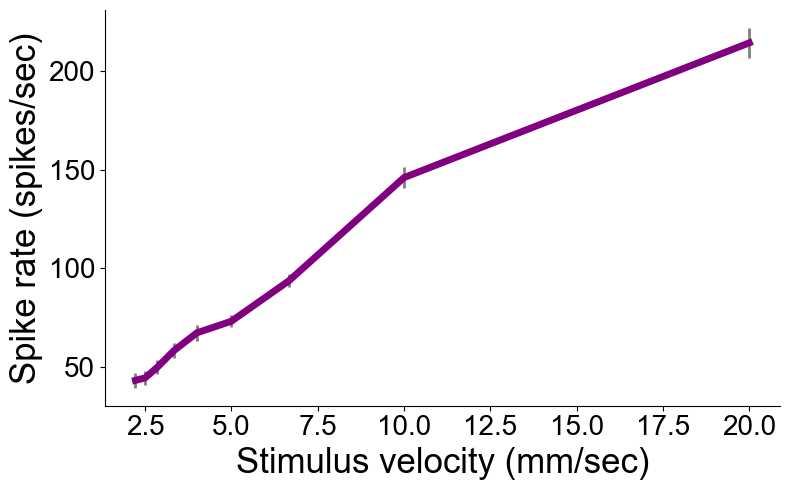

In [231]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

SR = 40000  # sampling rate

# --- define amplitudes and their corresponding stimulus times (will turn to stim velocity later) ---
stim_velocity = np.array([0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5])

triangle_windows = [
    (8.00, 8.45),
    (8.75, 9.15),
    (9.50, 9.85),
    (10.25, 10.55),
    (11.0, 11.25),
    (11.75, 11.95),
    (12.50, 12.65),
    (13.25, 13.35),
    (14.00, 14.05),
]


# --- analyze first 5 trials (channel 0) ---
blocks_to_analyze = ['block_0', 'block_1', 'block_2', 'block_3', 'block_4','block_5', 'block_6', 'block_7', 'block_8', 'block_9',
                     'block_10', 'block_11', 'block_12', 'block_13', 'block_14','block_15', 'block_16', 'block_17', 'block_18', 'block_19',
                     'block_20', 'block_21', 'block_22', 'block_23', 'block_24','block_25', 'block_26', 'block_27', 'block_28', 'block_29',
                     'block_30', 'block_31', 'block_32', 'block_33', 'block_34','block_35', 'block_36', 'block_37', 'block_38', 'block_39',
                     'block_40', 'block_41', 'block_42', 'block_43', 'block_44','block_45', 'block_46', 'block_47', 'block_48', 'block_49',
                     'block_50', 'block_51', 'block_52', 'block_53', 'block_54','block_55', 'block_56', 'block_57', 'block_58', 'block_59',]
channel_index = 0

# store spike rate data across trials
all_spike_rates = []

for block_id in blocks_to_analyze:

    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR

    # detect spikes (use the height you’ve already tuned)
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
    spike_times = time[peaks]

    # compute spike rates for each amplitude window
    spike_rates = []


    for (t_start, t_end) in triangle_windows:
        spikes_in_window = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_window / (t_end - t_start)
        spike_rates.append(rate)
 
    all_spike_rates.append(spike_rates)


# --- convert list to numpy array (shape: trials × amplitudes) ---
all_spike_rates = np.array(all_spike_rates)


# --- compute mean and SEM across trials ---
mean_rates = np.mean(all_spike_rates, axis=0)
sem_rates = np.std(all_spike_rates, axis=0, ddof=1) / np.sqrt(all_spike_rates.shape[0])

# --- stim_velocity calculation and from V to mm ---
triangle_durations = np.array([t_end - t_start for t_start, t_end in triangle_windows])
half_time = triangle_durations / 2
stim_velocity_mV = stim_velocity / half_time
stim_velocity_mV = stim_velocity_mV * 1000
stim_velocity_mm = stim_velocity_mV *.001

# --- final plot: averaged spike rate vs amplitude ---
plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(8, 5))
plt.errorbar(stim_velocity_mm, mean_rates, yerr=sem_rates, fmt='-', capsize=0, color='purple', ecolor='gray', linewidth=5, elinewidth=2)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Stimulus velocity (mm/sec)", fontsize=25)
plt.ylabel("Spike rate (spikes/sec)", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.tight_layout()
plt.show()

In [233]:
# --- Print first and last spike rate values ---
print("=== Spike Rate Values ===")
print(f"Start window  - First: {mean_rates[0]:.2f} spikes/s +/- {sem_rates [0]:.2f}| Last: {mean_rates[-1]:.2f} spikes/s +/- {sem_rates [-1]:.2f}")


=== Spike Rate Values ===
Start window  - First: 43.19 spikes/s +/- 3.75| Last: 214.33 spikes/s +/- 7.53


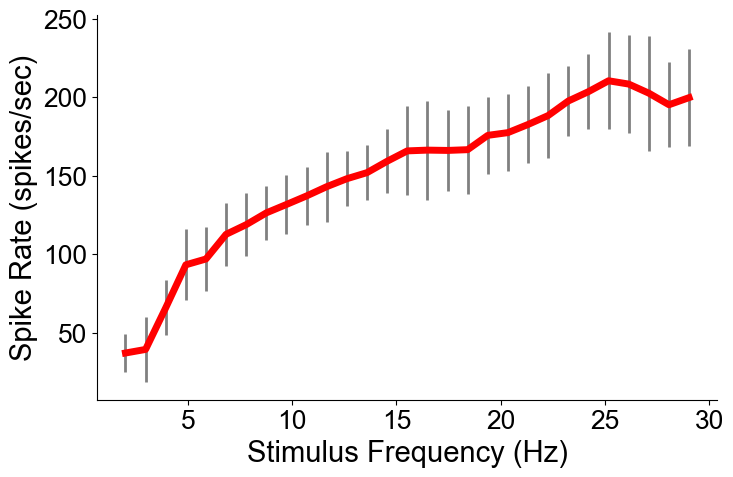

In [242]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from collections import defaultdict

SR = 40000  # sampling rate
channel_index = 0
trial_duration = 15  # seconds
n_trials = 60

# Frequencies of interest
f_start = 2
f_end = 30
n_bins = 30  # number of frequency bins
freq_bins = np.linspace(f_start, f_end, n_bins)

# This dict should contain your 60 trial recordings: Sine_chirps_Trials[trial_index][channel]
n_trials = ['block_60', 'block_61', 'block_62', 'block_63', 'block_64','block_65', 'block_66', 'block_67', 'block_68', 'block_69',
                     'block_70', 'block_71', 'block_72', 'block_73', 'block_74','block_75', 'block_76', 'block_77', 'block_78', 'block_79',
                     'block_80', 'block_81', 'block_82', 'block_83', 'block_84','block_85', 'block_86', 'block_87', 'block_88', 'block_89',
                     'block_90', 'block_91', 'block_92', 'block_93', 'block_94','block_95', 'block_96', 'block_97', 'block_98', 'block_99',
                     'block_100', 'block_101', 'block_102', 'block_103', 'block_104','block_105', 'block_106', 'block_107', 'block_108', 'block_109',
                     'block_110', 'block_111', 'block_112', 'block_113', 'block_114','block_115', 'block_116', 'block_117', 'block_118', 'block_119',]


# --- Bin spike counts by frequency ---
freq_to_rates = defaultdict(list)

for trial in n_trials:
    data = Sine_chirps_Trials[trial][channel_index]
    time = np.arange(len(data)) / SR

    # detect spikes
    peaks, _ = find_peaks(data, height=0.025, distance=int(SR * 0.001))
    spike_times = time[peaks]

    # map spike times to frequency bins
    for f in freq_bins:
        # assume linear sweep: frequency at time t = f_start + (f_end - f_start) * t / trial_duration
        t_start = (f - f_start) / (f_end - f_start) * trial_duration
        t_end = (f + (freq_bins[1]-freq_bins[0]) - f_start) / (f_end - f_start) * trial_duration

        spikes_in_bin = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_bin / (t_end - t_start)
        freq_to_rates[f].append(rate)

# --- Compute mean and std across trials ---
mean_rates = [np.mean(freq_to_rates[f]) for f in freq_bins]
std_rates = [np.std(freq_to_rates[f]) for f in freq_bins]

# exclude last bin
freq_bins_plot = freq_bins[:-1]
mean_rates_plot = mean_rates[:-1]
std_rates_plot = std_rates[:-1]


# --- Plot ---
plt.figure(figsize=(8,5))
plt.errorbar(freq_bins_plot, mean_rates_plot, yerr=std_rates_plot, fmt='-', color='red',
             ecolor='gray', linewidth = 5, elinewidth=2)
plt.xlabel("Stimulus Frequency (Hz)", fontsize=21)
plt.ylabel("Spike Rate (spikes/sec)", fontsize=21)
# Increase tick font size
plt.tick_params(axis='x', labelsize=19)
plt.tick_params(axis='y', labelsize=19)
# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()



In [243]:
# --- Print first and last spike rate values ---
print("=== Spike Rate Values ===")
print(f"Start window  - First: {mean_rates_plot[0]:.2f} spikes/s +/- {std_rates_plot [0]:.2f}| Last: {mean_rates_plot[-1]:.2f} spikes/s +/- {std_rates_plot [-1]:.2f}")


=== Spike Rate Values ===
Start window  - First: 36.96 spikes/s +/- 12.16| Last: 199.65 spikes/s +/- 31.10


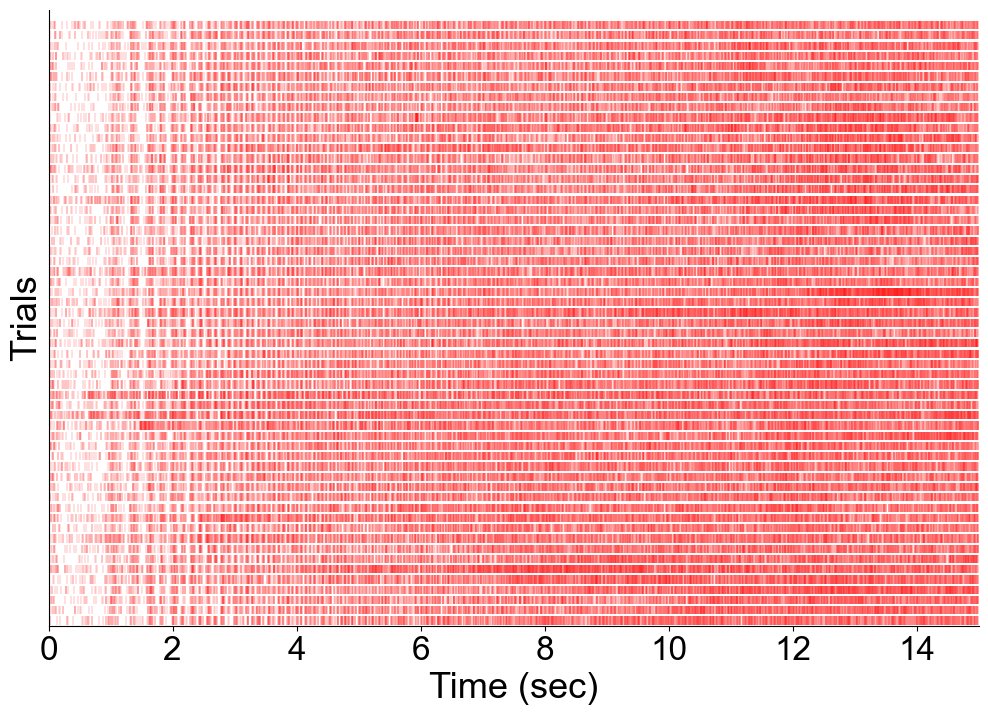

In [234]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np

SR = 40000
channel_index = 0
trial_duration = 15  # seconds
trial_keys = ['block_60', 'block_61', 'block_62', 'block_63', 'block_64','block_65', 
              'block_66', 'block_67', 'block_68', 'block_69', 'block_70', 'block_71', 
              'block_72', 'block_73', 'block_74','block_75', 'block_76', 'block_77', 
              'block_78', 'block_79', 'block_80', 'block_81', 'block_82', 'block_83', 
              'block_84','block_85', 'block_86', 'block_87', 'block_88', 'block_89',
              'block_90', 'block_91', 'block_92', 'block_93', 'block_94','block_95', 
              'block_96', 'block_97', 'block_98', 'block_99','block_100', 'block_101', 
              'block_102', 'block_103', 'block_104','block_105', 'block_106', 'block_107', 
              'block_108', 'block_109','block_110', 'block_111', 'block_112', 'block_113', 
              'block_114','block_115', 'block_116', 'block_117', 'block_118', 'block_119']

# Collect spike times for each trial
all_spike_times = []

for trial in trial_keys:
    data = Sine_chirps_Trials[trial][channel_index]
    time = np.arange(len(data)) / SR

    # Detect spikes
    peaks, _ = find_peaks(data, height=0.025, distance=int(SR*0.001))
    spike_times = time[peaks]

    # Limit spikes to 0-15 sec
    spike_times = spike_times[spike_times <= trial_duration]

    all_spike_times.append(spike_times)

# --- Create figure and axes ---
fig, ax = plt.subplots(figsize=(12, 8))
tick_size = 0.8  # length of spike marks

# Plot raster using ax.eventplot
ax.eventplot(all_spike_times, colors='red', lineoffsets=1, linelengths=0.8, linewidths=0.35, alpha =0.5)

# Axis labels, title, and limits
ax.set_xlabel("Time (sec)", fontsize=26)
ax.set_ylabel("Trials", fontsize=26)
ax.set_xlim(0, trial_duration)
ax.set_ylim(0.5, len(trial_keys)+0.5)
ax.tick_params(axis='y', left=False, right=False, labelleft=False)
ax.set_yticks(range(1, len(trial_keys)+1))
ax.tick_params(axis='x', labelsize=24)  # set to whatever size you want

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


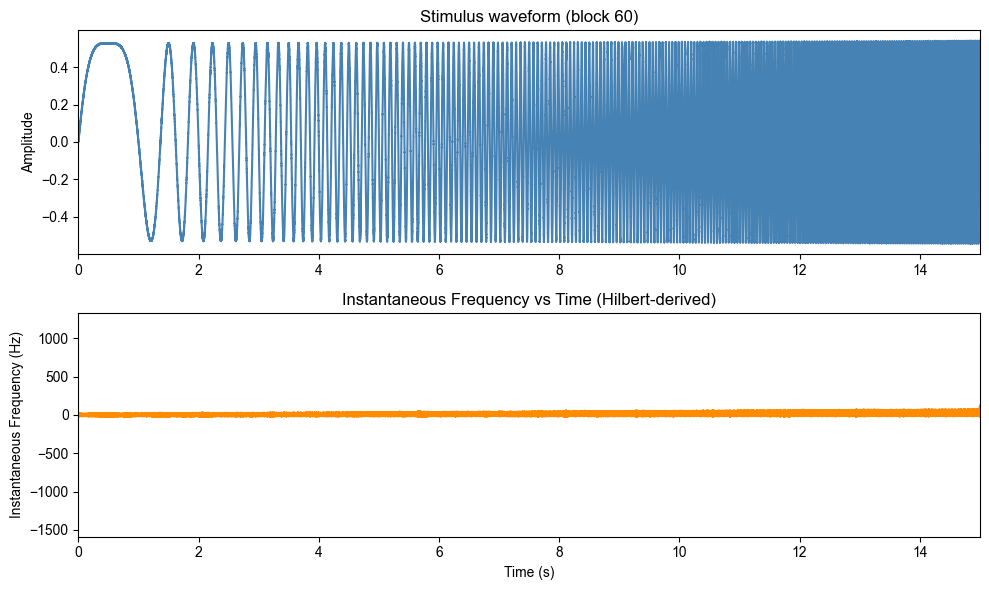

Frequency range detected: -1455.6 Hz → 1196.0 Hz


In [33]:
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import numpy as np

# pick one block for testing
block = 'block_60'

stim_signal = Sine_chirps_Trials[block][1]  # assuming channel 1 = stimulus
t = np.arange(len(stim_signal)) / dataset.fs

# Compute instantaneous frequency using Hilbert transform
analytic_signal = hilbert(stim_signal)
inst_phase = np.unwrap(np.angle(analytic_signal))
inst_freq = np.diff(inst_phase) / (2 * np.pi) * dataset.fs

# Time base for inst_freq (1 sample shorter)
t_freq = t[1:]

# --- Plot ---
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(t, stim_signal, color='steelblue')
plt.xlim(0, 15)  # show first 15 seconds (the chirp)
plt.title("Stimulus waveform (block 60)")
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
plt.plot(t_freq, inst_freq, color='darkorange')
plt.xlim(0, 15)
plt.ylabel("Instantaneous Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("Instantaneous Frequency vs Time (Hilbert-derived)")

plt.tight_layout()
plt.show()
print(f"Frequency range detected: {np.nanmin(inst_freq):.1f} Hz → {np.nanmax(inst_freq):.1f} Hz")


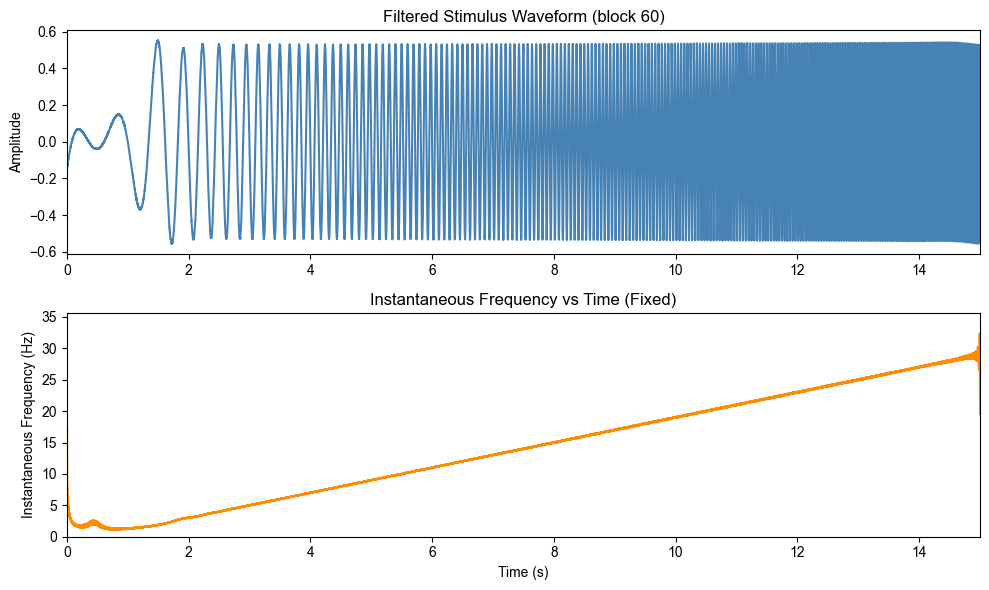

Estimated frequency sweep: -1.1 Hz → 32.4 Hz


In [89]:
from scipy.signal import hilbert, butter, filtfilt
import matplotlib.pyplot as plt
import numpy as np

block = 'block_60'
stim_signal = Sine_chirps_Trials[block][1]
t = np.arange(len(stim_signal)) / dataset.fs

# --- preprocess ---
stim_signal = stim_signal - np.mean(stim_signal)        # center signal
b, a = butter(3, [1, 5000], btype='bandpass', fs=dataset.fs)  # keep 1–5 kHz if your chirp is in this range
stim_filt = filtfilt(b, a, stim_signal)

# --- Hilbert transform ---
analytic = hilbert(stim_filt)
inst_phase = np.unwrap(np.angle(analytic))
inst_freq = np.diff(inst_phase) / (2*np.pi) * dataset.fs
t_freq = t[1:]

# --- smooth the freq trace ---
window = int(0.01 * dataset.fs)  # 10 ms smoothing window
inst_freq_smooth = np.convolve(inst_freq, np.ones(window)/window, mode='same')

# --- plot ---
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(t, stim_filt, color='steelblue')
plt.xlim(0, 15)
plt.title("Filtered Stimulus Waveform (block 60)")
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
plt.plot(t_freq, inst_freq_smooth, color='darkorange')
plt.xlim(0, 15)
plt.ylim(0, np.nanmax(inst_freq_smooth)*1.1)
plt.ylabel("Instantaneous Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("Instantaneous Frequency vs Time (Fixed)")

plt.tight_layout()
plt.show()

print(f"Estimated frequency sweep: {np.nanmin(inst_freq_smooth):.1f} Hz → {np.nanmax(inst_freq_smooth):.1f} Hz")


Auto-detected stimulus channel = 1 (0 or 1). If this is wrong, swap channels manually.
Block 60: inst freq range: -50.00 – 10.61 Hz


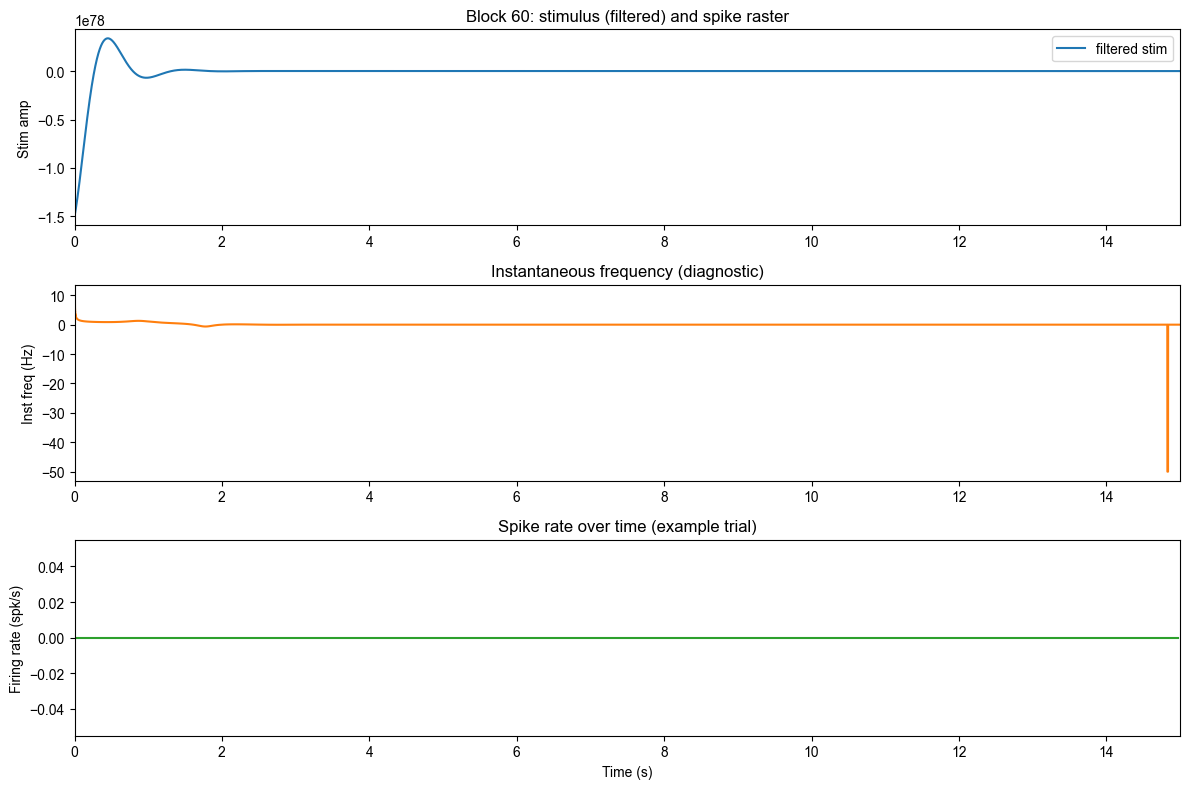

Per-trial spike counts (chirp period): n=60, min=0, mean=0.0, max=0
Total binned points: 18000


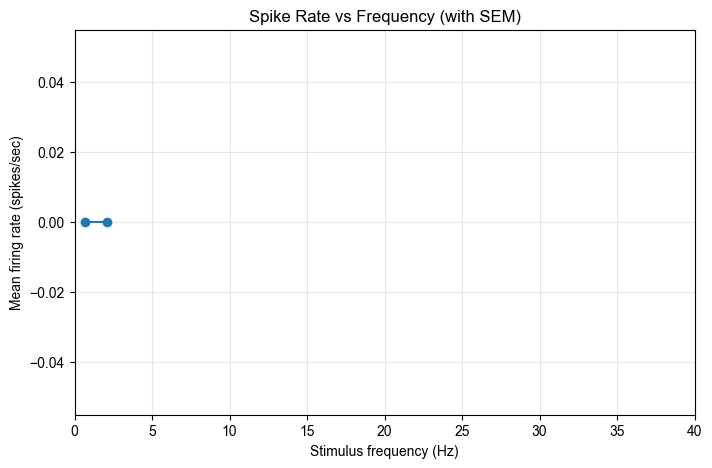

In [91]:
# Robust diagnostic + analysis pipeline
# - auto-detect stimulus channel
# - compute cleaned instantaneous frequency
# - detect spikes and print counts
# - plot stimulus + inst freq + raster + spike-rate over time
# - final spike-rate vs frequency with SEM error bars

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
import warnings
warnings.filterwarnings('ignore')

# params
window_size = int(0.001 * dataset.fs)   # spike detection window (samples)
bin_size = 0.05                         # seconds per time bin for firing rate
stim_duration = 15.0                    # duration of chirp in seconds (0->15)
freq_bins = np.linspace(0, 40, 30)      # adjust to expected freq range (Hz)
low_bp = 0.1                            # bandpass low cut (Hz)
high_bp = 500                           # bandpass high cut (Hz)

def bandpass_filter(x, fs, low, high, order=3):
    b, a = butter(order, [low, high], btype='bandpass', fs=fs)
    return filtfilt(b, a, x)

def compute_inst_freq(signal, fs, low=low_bp, high=high_bp):
    sig = signal - np.mean(signal)
    sig_f = bandpass_filter(sig, fs, low, high)
    analytic = hilbert(sig_f)
    phase = np.unwrap(np.angle(analytic))
    inst_freq = np.diff(phase) / (2*np.pi) * fs
    t_freq = np.arange(1, len(signal)) / fs
    # small smoothing for stability (10 ms window)
    window = max(1, int(0.01 * fs))
    inst_freq_smooth = np.convolve(inst_freq, np.ones(window)/window, mode='same')
    return t_freq, inst_freq_smooth, sig_f

# --- auto-detect stimulus channel by spectral power in expected chirp band ---
def detect_stim_channel(block_idx):
    # examine both channels and choose the one with higher power in [1, 100] Hz band
    pows = []
    for ch in (0,1):
        sig = Sine_chirps_Trials[f'block_{block_idx}'][ch]
        sig = sig - np.mean(sig)
        # bandpass to expected chirp range
        filt = bandpass_filter(sig, dataset.fs, 0.5, 200)  # tweak if needed
        pows.append(np.mean(filt**2))
    # choose channel with higher power as stimulus
    stim_ch = 0 if pows[0] > pows[1] else 1
    return stim_ch

# --- main loop: build arrays for plotting and aggregation ---
all_freqs = []         # list of frequency values (per time-bin across trials)
all_spike_rates = []   # matching spike rates
per_trial_spike_counts = []

# use block_60 to detect stimulus channel once (should be consistent)
stim_ch_guess = detect_stim_channel(60)
print(f"Auto-detected stimulus channel = {stim_ch_guess} (0 or 1). If this is wrong, swap channels manually.")

# Diagnostic: make a diagnostic plot for block_60
block0 = 'block_60'
neural0 = Sine_chirps_Trials[block0][1 - stim_ch_guess]   # the other channel
stim0 = Sine_chirps_Trials[block0][stim_ch_guess]

t = np.arange(len(stim0)) / dataset.fs
t_freq0, inst_freq0, stim0_filt = compute_inst_freq(stim0, dataset.fs, low=0.1, high=500)
print(f"Block 60: inst freq range: {np.nanmin(inst_freq0):.2f} – {np.nanmax(inst_freq0):.2f} Hz")

# detect spikes in one example trial to visualize
spike_times0 = ntk.detect_spikes(neural0, fs=dataset.fs, window_size=window_size)
spike_times0 = spike_times0[spike_times0 < stim_duration]

# Plot diagnostic for block_60
plt.figure(figsize=(12,8))
ax1 = plt.subplot(3,1,1)
ax1.plot(t, stim0_filt, label='filtered stim', color='tab:blue')
ax1.set_xlim(0, stim_duration)
ax1.set_ylabel('Stim amp')
ax1.set_title(f'Block 60: stimulus (filtered) and spike raster')
# overlay spike times on top (vertical lines)
for st in spike_times0:
    if st < stim_duration:
        ax1.axvline(st, ymin=0.02, ymax=0.15, color='k', alpha=0.6)
ax1.legend()

ax2 = plt.subplot(3,1,2, sharex=ax1)
ax2.plot(t_freq0, inst_freq0, color='tab:orange')
ax2.set_xlim(0, stim_duration)
ax2.set_ylabel('Inst freq (Hz)')
ax2.set_title('Instantaneous frequency (diagnostic)')

# compute spike rate over time for example trial
time_bins = np.arange(0, stim_duration + bin_size, bin_size)
spike_counts0, _ = np.histogram(spike_times0, bins=time_bins)
spike_rate0 = spike_counts0 / bin_size
ax3 = plt.subplot(3,1,3, sharex=ax1)
ax3.plot(time_bins[:-1] + bin_size/2, spike_rate0, color='tab:green')
ax3.set_xlim(0, stim_duration)
ax3.set_ylabel('Firing rate (spk/s)')
ax3.set_xlabel('Time (s)')
ax3.set_title('Spike rate over time (example trial)')
plt.tight_layout()
plt.show()

# --- iterate through all chirp blocks and aggregate ---
for block in range(60, 120):
    trial_key = f'block_{block}'
    stim = Sine_chirps_Trials[trial_key][stim_ch_guess]
    neural = Sine_chirps_Trials[trial_key][1 - stim_ch_guess]
    
    # instantaneous frequency (and filtered stim)
    t_freq, inst_freq, _ = compute_inst_freq(stim, dataset.fs, low=0.1, high=500)
    
    # crop to chirp duration
    mask_time = t_freq < stim_duration
    t_freq_c = t_freq[mask_time]
    inst_freq_c = inst_freq[mask_time]
    if len(inst_freq_c) == 0:
        print(f"Warning: block {block} has no inst_freq in first {stim_duration}s.")
        continue
    
    # detect spikes and crop to chirp_duration
    spike_times = ntk.detect_spikes(neural, fs=dataset.fs, window_size=window_size)
    spike_times = spike_times[spike_times < stim_duration]
    per_trial_spike_counts.append(len(spike_times))
    
    # bin spike rate across chirp_duration
    time_bins = np.arange(0, stim_duration + bin_size, bin_size)
    spike_counts, _ = np.histogram(spike_times, bins=time_bins)
    spike_rate = spike_counts / bin_size
    time_bin_centers = time_bins[:-1] + bin_size/2
    
    # map frequency to each time bin by interpolation
    # ensure t_freq_c covers the needed range (it should)
    freq_binned = np.interp(time_bin_centers, t_freq_c, inst_freq_c, left=np.nan, right=np.nan)
    
    # drop time bins with NaN freq (outside freq extraction)
    valid = ~np.isnan(freq_binned)
    freq_binned = freq_binned[valid]
    spike_rate = spike_rate[valid]
    
    # accumulate
    all_freqs.append(freq_binned)
    all_spike_rates.append(spike_rate)

# flatten lists
if len(all_freqs) == 0:
    raise RuntimeError("No frequency/time bins were gathered. Check stim_duration or data.")
all_freqs_flat = np.concatenate(all_freqs)
all_spike_rates_flat = np.concatenate(all_spike_rates)

# quick summary of spike detection
print(f"Per-trial spike counts (chirp period): n={len(per_trial_spike_counts)}, min={np.min(per_trial_spike_counts)}, mean={np.mean(per_trial_spike_counts):.1f}, max={np.max(per_trial_spike_counts)}")
print(f"Total binned points: {len(all_freqs_flat)}")

# --- compute mean and SEM per frequency bin ---
import scipy.stats as stats
mean_rates = []
sem_rates = []
bin_centers = (freq_bins[:-1] + freq_bins[1:]) / 2
for f0, f1 in zip(freq_bins[:-1], freq_bins[1:]):
    mask = (all_freqs_flat >= f0) & (all_freqs_flat < f1)
    vals = all_spike_rates_flat[mask]
    if len(vals) >= 1:
        mean_rates.append(np.nanmean(vals))
        sem_rates.append(stats.sem(vals, nan_policy='omit'))
    else:
        mean_rates.append(np.nan)
        sem_rates.append(np.nan)

# --- final plot: mean +/- SEM ---
plt.figure(figsize=(8,5))
plt.errorbar(bin_centers, mean_rates, yerr=sem_rates, fmt='-o', ecolor='gray', capsize=3)
plt.xlabel('Stimulus frequency (Hz)')
plt.ylabel('Mean firing rate (spikes/sec)')
plt.title('Spike Rate vs Frequency (with SEM)')
plt.grid(True, alpha=0.3)
plt.xlim(freq_bins[0], freq_bins[-1])
plt.show()


In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt
import neurotoolkit as ntk  # adjust if different

SR = dataset.fs
trial_signal = dataset['block_60'][0].astype(np.float64)  # ensure float64

# ---- Filter stimulus ----
lowcut, highcut = 1, 1000  # adjust based on experiment range
b, a = butter(4, [lowcut/(SR/2), highcut/(SR/2)], btype='band')
stim_filt = filtfilt(b, a, trial_signal)

# ---- Instantaneous frequency ----
analytic_signal = hilbert(stim_filt)
inst_phase = np.unwrap(np.angle(analytic_signal))
inst_freq = np.diff(inst_phase) / (2 * np.pi) * SR
t_inst = np.arange(len(inst_freq)) / SR

# ---- Sanity check plot ----
plt.figure(figsize=(11, 6))
plt.subplot(2, 1, 1)
plt.plot(np.arange(len(stim_filt))/SR, stim_filt)
plt.title("Filtered Stimulus Waveform")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(t_inst, inst_freq, color='orange')
plt.title("Instantaneous Frequency (Diagnostic)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

print(f"Instantaneous frequency range: {np.nanmin(inst_freq):.2f}–{np.nanmax(inst_freq):.2f} Hz")

# ---- Spike detection ----
spike_times = ntk.detect_spikes(stim_filt, fs=SR, window_size=0.002)  # tweak window
print(f"Detected {len(spike_times)} spikes")

# ---- Spike rate (per second) ----
bin_size = 0.05
time_bins = np.arange(0, len(trial_signal)/SR, bin_size)
spike_counts, _ = np.histogram(spike_times, bins=time_bins)
spike_rate = spike_counts / bin_size
time_centers = time_bins[:-1] + bin_size/2

# ---- Frequency vs spike rate ----
freq_downsampled = np.interp(time_centers, t_inst, inst_freq)

plt.figure(figsize=(9,6))
plt.scatter(freq_downsampled, spike_rate, color='green', s=8)
plt.xlabel("Stimulus Frequency (Hz)")
plt.ylabel("Firing Rate (spikes/s)")
plt.title("Firing Rate vs Stimulus Frequency")
plt.show()


ModuleNotFoundError: No module named 'neurotoolkit'

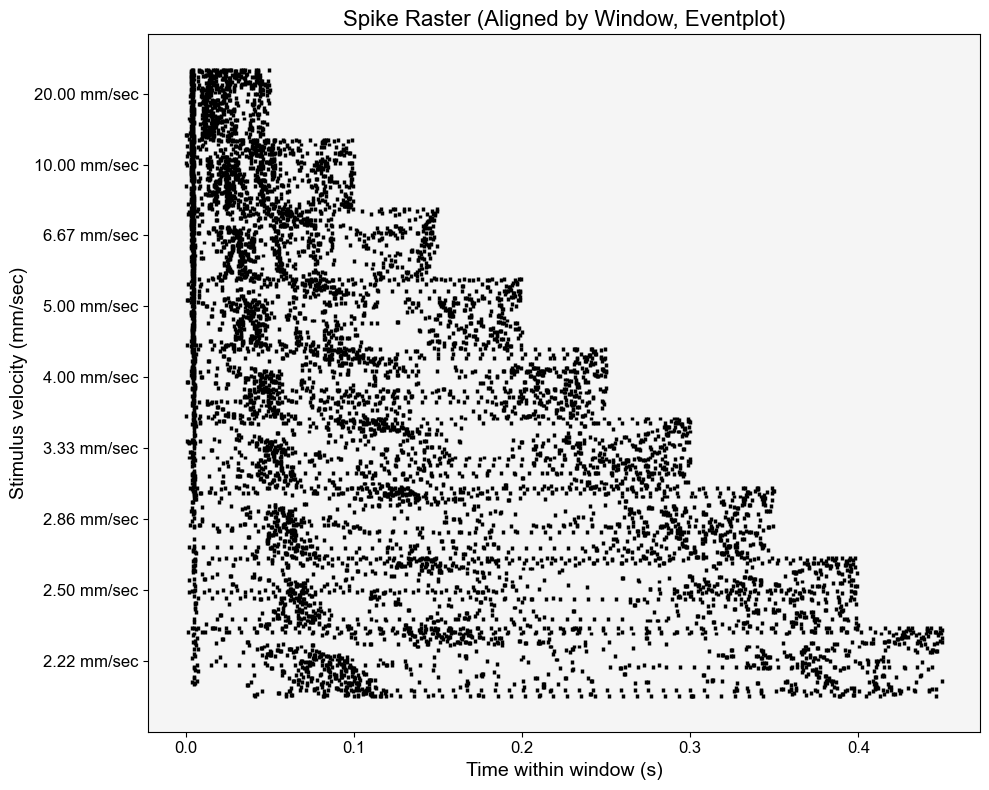

In [80]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

SR = 40000
num_trials_to_plot = 60

# --- Collect spike times aligned to each window, per trial ---
all_window_spikes = []  # list of lists of aligned spike times for each window

for i, (t_start, t_end) in enumerate(triangle_windows):
    window_spikes = []  # one entry per trial
    for trial_idx, block_id in enumerate(blocks_to_analyze[:num_trials_to_plot]):
        data = Step_triangles_Trials[block_id][channel_index]
        time = np.arange(len(data)) / SR
        peaks, _ = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
        spike_times = time[peaks]

        # align spikes to window start (so 0 = start of window)
        spikes_in_window = spike_times[(spike_times >= t_start) & (spike_times < t_end)]
        aligned_spikes = spikes_in_window - t_start
        window_spikes.append(aligned_spikes)
    all_window_spikes.append(window_spikes)

# --- Plot raster ---
fig, ax = plt.subplots(figsize=(10, 8))

trial_spacing = 0.15

current_offset = 0
for i, window_spikes in enumerate(all_window_spikes):
    offsets = np.arange(len(window_spikes)) * trial_spacing + current_offset
    ax.eventplot(
        window_spikes,
        lineoffsets=offsets,
        linelengths=0.5,    # vertical tick length
        linewidths=2.5,     # tick thickness
        color='black',
    )
    # no window spacing, just stack continuously
    current_offset += len(window_spikes) * trial_spacing

# --- Compute velocities (mm/sec) ---
triangle_durations = np.array([t_end - t_start for t_start, t_end in triangle_windows])
half_time = triangle_durations / 2
stim_velocity_mV = stim_velocity / half_time
stim_velocity_mV = stim_velocity_mV * 1000
stim_velocity_mm = stim_velocity_mV * 0.001  # convert mV/ms to mm/sec

# --- labeling ---
yticks = []
yticklabels = []
offset = 0
for i, vel in enumerate(stim_velocity_mm):
    yticks.append(offset + (num_trials_to_plot * trial_spacing) / 2)
    yticklabels.append(f"{vel:.2f} mm/sec")
    offset += num_trials_to_plot * trial_spacing  # no added window spacing

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

ax.set_xlabel("Time within window (s)", fontsize=14)
ax.set_ylabel("Stimulus velocity (mm/sec)", fontsize=14)
ax.set_title("Spike Raster (Aligned by Window, Eventplot)", fontsize=16)
ax.tick_params(axis='both', labelsize=12)
ax.set_facecolor('whitesmoke')

plt.tight_layout()
plt.show()


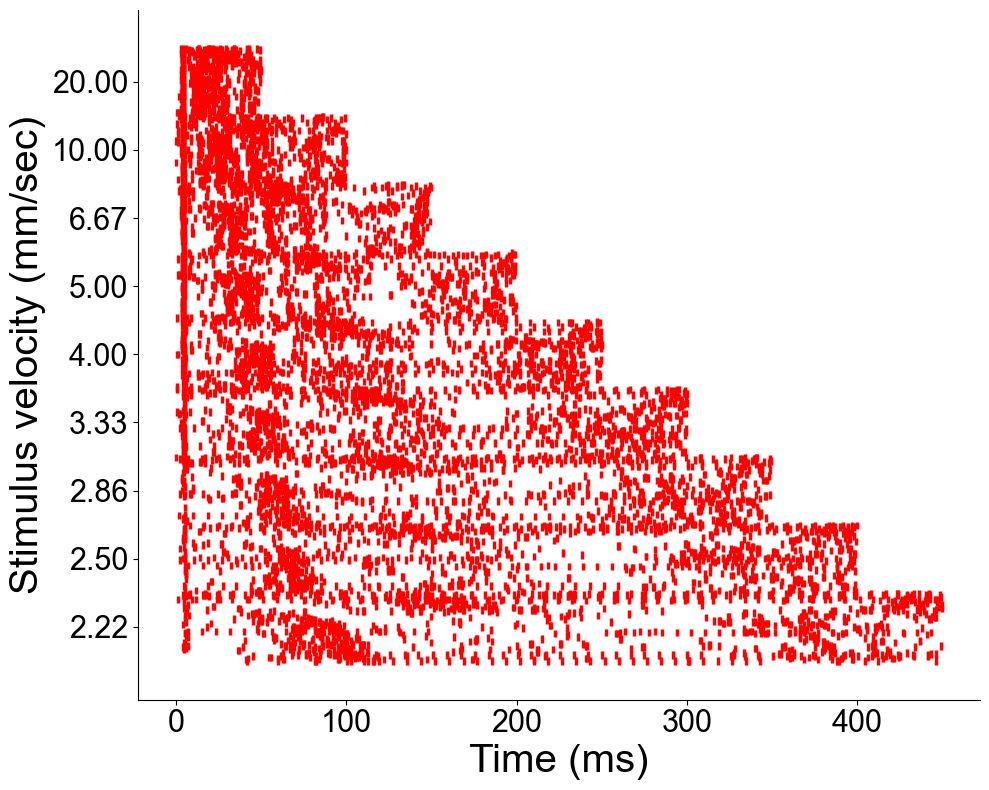

In [212]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

SR = 40000
num_trials_to_plot = 60

# --- Collect spike times aligned to each window, per trial ---
all_window_spikes = []  # list of lists of aligned spike times for each window

for i, (t_start, t_end) in enumerate(triangle_windows):
    window_spikes = []  # one entry per trial
    for trial_idx, block_id in enumerate(blocks_to_analyze[:num_trials_to_plot]):
        data = Step_triangles_Trials[block_id][channel_index]
        time = np.arange(len(data)) / SR
        peaks, _ = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
        spike_times = time[peaks]

        # align spikes to window start (so 0 = start of window)
        spikes_in_window = spike_times[(spike_times >= t_start) & (spike_times < t_end)]
        aligned_spikes = (spikes_in_window - t_start) * 1000  # convert to ms
        window_spikes.append(aligned_spikes)
    all_window_spikes.append(window_spikes)

# --- Plot raster ---
fig, ax = plt.subplots(figsize=(10, 8))

trial_spacing = 0.15
current_offset = 0

for i, window_spikes in enumerate(all_window_spikes):
    offsets = np.arange(len(window_spikes)) * trial_spacing + current_offset
    ax.eventplot(
        window_spikes,
        lineoffsets=offsets,
        linelengths=1,
        linewidths=2.5,
        color='red',
    )
    current_offset += len(window_spikes) * trial_spacing

# --- Compute velocities (mm/sec) ---
triangle_durations = np.array([t_end - t_start for t_start, t_end in triangle_windows])
half_time = triangle_durations / 2
stim_velocity_mV = stim_velocity / half_time
stim_velocity_mV = stim_velocity_mV * 1000
stim_velocity_mm = stim_velocity_mV * 0.001

# --- labeling ---
yticks = []
yticklabels = []
offset = 0
for i, vel in enumerate(stim_velocity_mm):
    yticks.append(offset + (num_trials_to_plot * trial_spacing) / 2)
    yticklabels.append(f"{vel:.2f}")
    offset += num_trials_to_plot * trial_spacing

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=22)  # ← bigger y tick labels

ax.set_xlabel("Time (ms)", fontsize=29)  # ← bigger axis label
ax.set_ylabel("Stimulus velocity (mm/sec)", fontsize=29)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=22)  # ← bigger x tick labels
ax.tick_params(axis='y', labelsize=22)
ax.set_facecolor('white')

plt.tight_layout()
plt.show()


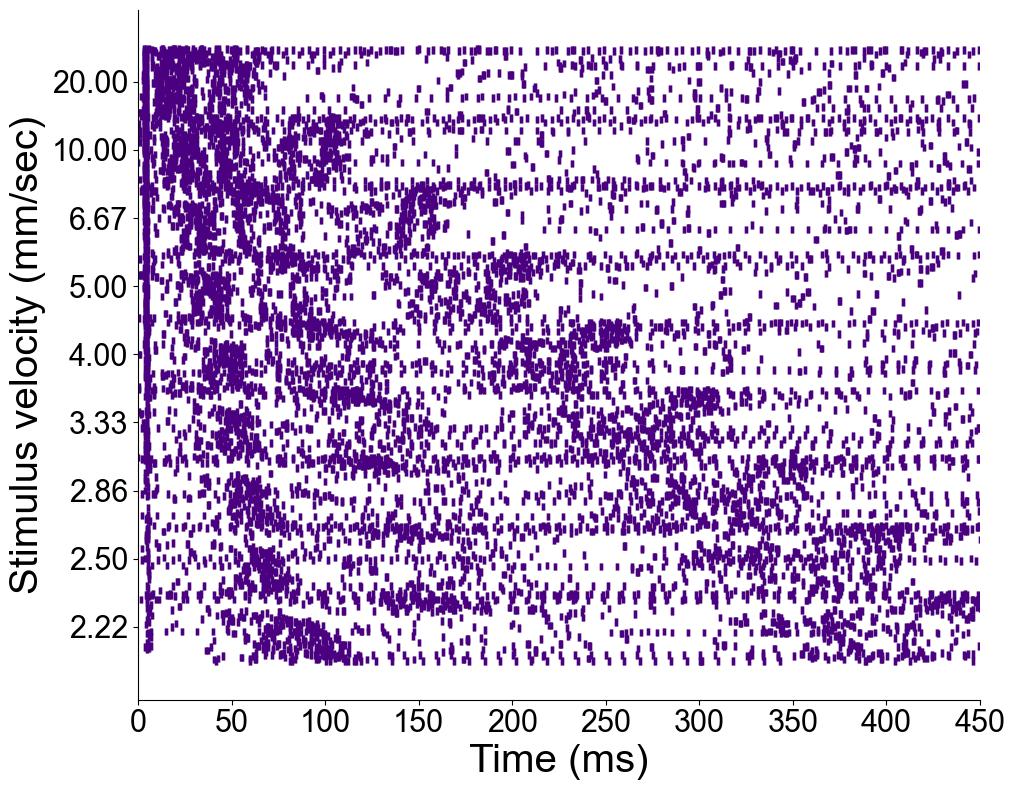

In [229]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

SR = 40000
num_trials_to_plot = 60

# --- Determine fixed window length ---
fixed_window_length = max([t_end - t_start for t_start, t_end in triangle_windows])

# --- Collect spike times aligned to fixed window ---
all_window_spikes = []

for i, (t_start, t_end) in enumerate(triangle_windows):
    window_spikes = []
    for trial_idx, block_id in enumerate(blocks_to_analyze[:num_trials_to_plot]):
        data = Step_triangles_Trials[block_id][channel_index]
        time = np.arange(len(data)) / SR
        peaks, _ = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
        spike_times = time[peaks]

        t_fixed_end = t_start + fixed_window_length
        spikes_in_window = spike_times[(spike_times >= t_start) & (spike_times < t_fixed_end)]
        aligned_spikes = (spikes_in_window - t_start) * 1000
        window_spikes.append(aligned_spikes)
    all_window_spikes.append(window_spikes)

# --- Plot raster ---
fig, ax = plt.subplots(figsize=(10, 8))
trial_spacing = 0.15
current_offset = 0

for i, window_spikes in enumerate(all_window_spikes):
    offsets = np.arange(len(window_spikes)) * trial_spacing + current_offset
    ax.eventplot(
        window_spikes,
        lineoffsets=offsets,
        linelengths=1,
        linewidths=2.5,
        color='darkgrey',
    )
    current_offset += len(window_spikes) * trial_spacing

# --- Compute velocities ---
triangle_durations = np.array([t_end - t_start for t_start, t_end in triangle_windows])
half_time = triangle_durations / 2
stim_velocity_mV = stim_velocity / half_time * 1000
stim_velocity_mm = stim_velocity_mV * 0.001

current_offset = 0
trial_spacing = 0.15

for i, window_spikes in enumerate(all_window_spikes):
    # plot spikes for this window
    offsets = np.arange(len(window_spikes)) * trial_spacing + current_offset
    ax.eventplot(
        window_spikes,
        lineoffsets=offsets,
        linelengths=1,
        linewidths=2.5,
        color='indigo',
    )

    # stimulus end time for this window (in ms)
    stim_end_time_ms = (triangle_windows[i][1] - triangle_windows[i][0]) * 1000

    # # draw the vertical line at stimulus offset
    # ax.axvline(
    #     x=stim_end_time_ms,
    #     ymin=(current_offset) / (num_trials_to_plot * trial_spacing * len(all_window_spikes)),
    #     ymax=(current_offset + num_trials_to_plot * trial_spacing) / (num_trials_to_plot * trial_spacing * len(all_window_spikes)),
    #     color='black',
    #     linestyle='--',
    #     linewidth=2,
    #     alpha=0.7
    # )

    current_offset += len(window_spikes) * trial_spacing


# --- Labeling ---
yticks = []
yticklabels = []
offset = 0
for i, vel in enumerate(stim_velocity_mm):
    yticks.append(offset + (num_trials_to_plot * trial_spacing) / 2)
    yticklabels.append(f"{vel:.2f}")
    offset += num_trials_to_plot * trial_spacing

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=22)
ax.set_xlabel("Time (ms)", fontsize=29)
ax.set_ylabel("Stimulus velocity (mm/sec)", fontsize=29)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='x', labelsize=22)
ax.tick_params(axis='y', labelsize=22)
ax.set_facecolor('white')
ax.set_xlim(0, fixed_window_length * 1000)

plt.tight_layout()
plt.show()


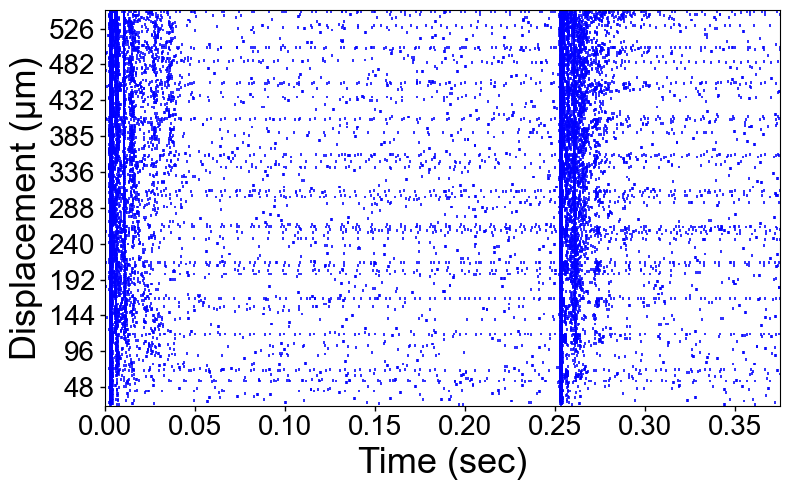

In [208]:
# --- COMPRESSED RASTER PLOT: spike times per trial, grouped by stimulus amplitude ---

plt.rcParams['font.family'] = 'Arial'

step_windows = [
    (1.50, 1.875),
    (2.00, 2.375),
    (2.50, 2.875),
    (3.00, 3.375),
    (3.50, 3.875),
    (4.00, 4.375),
    (4.50, 4.875),
    (5.00, 5.375),
    (5.50, 5.875),
    (6.00, 6.375),
    (6.50, 6.875)
]

trial_spike_times = []
for block_id in blocks_to_analyze:
    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
    trial_spike_times.append(time[peaks])
trial_spike_times = np.array(trial_spike_times, dtype=object)

n_trials = len(blocks_to_analyze)
n_amps = len(step_windows)
gap_rows = 1
window_dur = step_windows[0][1] - step_windows[0][0]

raster_data = []
line_offsets = []
group_centers = []

for a_idx, (t_start, t_end) in enumerate(step_windows):
    base = a_idx * (n_trials + gap_rows)
    for tr in range(n_trials):
        sp = trial_spike_times[tr]
        mask = (sp >= t_start) & (sp < t_end)
        sp_rel = sp[mask] - t_start
        raster_data.append(sp_rel)
        line_offsets.append(base + tr)
    group_centers.append(base + (n_trials - 1) / 2)

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.eventplot(
    raster_data,
    lineoffsets=line_offsets,
    linelengths=5,
    linewidths=1.15,
    colors='blue'   # notch color (raster lines)
)

plt.xlim(0, window_dur)
plt.xlabel("Time (sec)", fontsize=26)
plt.ylabel("Displacement (μm)", fontsize=26)

# Scale y-tick labels by 1000
plt.yticks(group_centers, [f"{amp * 1000:.0f}" for amp in amplitudes], fontsize=20)
plt.xticks(fontsize=20)

#  Make tick marks (notches) black
plt.tick_params(axis='y', colors='black', width=1)
plt.tick_params(axis='x', colors='black', width=1)

plt.ylim(-2, n_amps * (n_trials + gap_rows))
plt.tight_layout()
plt.show()
